In [204]:
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import warnings
import re
import numpy as np
warnings.filterwarnings("ignore")

In [205]:
########################################################################################
# Importar los datos
#########################################################################################
purchases = pd.read_csv("../pogit y replicacion de resultados/amazon-purchases.csv")
survey = pd.read_csv("../pogit y replicacion de resultados/survey.csv")
#########################################################################################
# Drop de columna con muchos valores nulos
##########################################################################################
survey.drop(columns=["Q-life-changes"], inplace=True)

#########################################################################################
# Drop de datos repetidos
########################################################################################

purchases = purchases.drop_duplicates()

########################################################################################
# Preparar columnas base
########################################################################################

purchases["Survey ResponseID"] = purchases["Survey ResponseID"].astype(str)

purchases["Order Date"] = pd.to_datetime(
    purchases["Order Date"],
    errors="coerce"
)

purchases["Purchase Price Per Unit"] = pd.to_numeric(
    purchases["Purchase Price Per Unit"],
    errors="coerce"
)

purchases["Quantity"] = pd.to_numeric(
    purchases["Quantity"],
    errors="coerce"
)

purchases["amount"] = (
    purchases["Purchase Price Per Unit"] * purchases["Quantity"]
)

########################################################################################
# Identificar productos electrónicos
########################################################################################

electronics_keywords = [
    r"\belectronics?\b",
    r"\bcomputer\b",
    r"\blaptop\b",
    r"\bnotebook\b",
    r"\bdesktop\b",
    r"\btablet\b",
    r"\bsmartphone\b",
    r"\bphone\b",
    r"\btv\b",
    r"\btelevision\b",
    r"\bmonitor\b",
    r"\bprojector\b",
    r"\bprinter\b",
    r"\bscanner\b",
    r"\bcamera\b",
    r"\bwebcam\b",
    r"\bspeaker\b",
    r"\baudio\b",
    r"\bsoundbar\b",
    r"\bheadphones?\b",
    r"\bheadset\b",
    r"\bearbuds?\b",
    r"\bmicrophone\b",
    r"\bcharger\b",
    r"\bcharging\b",
    r"\bbattery\b",
    r"\bpower(?: bank| supply)?\b",
    r"\badapter\b",
    r"\bcable\b",
    r"\bdock(?:ing)?(?: station)?\b",
    r"\bmouse\b",
    r"\bkeyboard\b",
    r"\btrackpad\b",
    r"\bcontroller\b",
    r"\bstylus\b",
    r"\bssd\b",
    r"\b(?:hard ?drive|hdd)\b",
    r"\b(?:flash ?drive|thumb ?drive)\b",
    r"\b(?:memory|ram)\b",
    r"\bgpu\b",
    r"\bgraphics card\b",
    r"\busb\b",
    r"\bbluetooth\b",
    r"\bhdmi\b",
    r"\bethernet\b",
    r"\b(?:wi[- ]?fi|wifi)\b",
    r"\bsmartwatch\b",
    r"\bwearable\b",
    r"\brouter\b",
    r"\bmodem\b",
    r"\bmesh(?: wifi)?\b",
    r"\btoner\b",
    r"\bink\b",
    r"\b(?:vr headset|virtual reality)\b"
]

electronics_pattern = "|".join(electronics_keywords)

purchases["is_tech"] = (
    purchases["Category"].astype(str).str.contains(
        electronics_pattern,
        case=False,
        regex=True,
        na=False
    )
    |
    purchases["Title"].astype(str).str.contains(
        electronics_pattern,
        case=False,
        regex=True,
        na=False
    )
)


########################################################################################
# Identificar Samsung
########################################################################################

purchases["is_samsung"] = purchases["Title"].astype(str).str.contains(
    r"\bsamsung\b",
    case=False,
    regex=True,
    na=False
)

########################################################################################
# Base de electrónicos
########################################################################################

purchases_tech = purchases[
    (purchases["is_tech"]) &
    (purchases["amount"] > 0) &
    (purchases["amount"] < 5000) &
    (purchases["Order Date"].notna())
].copy()


########################################################################################
# Base Samsung dentro de electrónicos
########################################################################################

purchases_samsung = purchases_tech[
    purchases_tech["is_samsung"]
].copy()

purchases_samsung.info(show_counts=True)

#####################################################################################
# Imputacion de valores nulos 
#####################################################################################

purchases_samsung = purchases_samsung.copy()

# Crear indicadores de ausencia antes de imputar
cols_con_nulos = [
    "Shipping Address State",
    "ASIN/ISBN (Product Code)",
    "Category"
]

for col in cols_con_nulos:
    purchases_samsung[f"{col}_missing"] = purchases_samsung[col].isna().astype(int)

# Imputación diferenciada
for col in ["Shipping Address State", "Category"]:
    moda = purchases_samsung[col].mode(dropna=True)[0]
    purchases_samsung[col] = purchases_samsung[col].fillna(moda)

purchases_samsung["ASIN/ISBN (Product Code)"] = (
    purchases_samsung["ASIN/ISBN (Product Code)"]
    .fillna("No informado")
)
####################################################################################
# Crear la variable "amount" como el producto del precio por unidad y la cantidad
####################################################################################
purchases_samsung["amount"] = (
    purchases_samsung["Purchase Price Per Unit"] * purchases_samsung["Quantity"]
)

## Filtrar filas completas, es decir, sin ningún dato nulo
datos_sin_nulos = purchases_samsung[
    purchases_samsung.notnull().all(axis=1)
].copy()

## Gasto total de las filas sin nulos
gasto_total_sin_nulos = datos_sin_nulos["amount"].sum()

######################################################################################
# Separar T1 y T2 para evitar data leakage
######################################################################################

# Filtrar primero la ventana T1
T1_START = pd.to_datetime("2018-01-01")
T1_END   = pd.to_datetime("2021-10-31")

T2_START = pd.to_datetime("2021-11-01")
T2_END   = pd.to_datetime("2023-03-19")


######################################################################################
# T1: Samsung para construir variables predictoras
######################################################################################

purchases_T1 = purchases_samsung[
    (purchases_samsung["Order Date"] >= T1_START) &
    (purchases_samsung["Order Date"] <= T1_END) &
    (purchases_samsung["amount"] > 0)
].copy()

######################################################################################
# T2: electrónicos totales para calcular ShoW empírico
######################################################################################

purchases_T2 = purchases_tech[
    (purchases_tech["Order Date"] >= T2_START) &
    (purchases_tech["Order Date"] <= T2_END) &
    (purchases_tech["amount"] > 0)
].copy()

######################################################################################
# Chequeos rápidos
######################################################################################

print("Compras totales:", purchases.shape)
print("Compras tech:", purchases_tech.shape)
print("Compras Samsung tech:", purchases_samsung.shape)
print("T1 Samsung:", purchases_T1.shape)
print("T2 tech:", purchases_T2.shape)

print("Clientes Samsung T1:", purchases_T1["Survey ResponseID"].nunique())
print("Clientes tech T2:", purchases_T2["Survey ResponseID"].nunique())

<class 'pandas.core.frame.DataFrame'>
Index: 14357 entries, 5 to 1850564
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Order Date                14357 non-null  datetime64[ns]
 1   Purchase Price Per Unit   14357 non-null  float64       
 2   Quantity                  14357 non-null  float64       
 3   Shipping Address State    13940 non-null  object        
 4   Title                     14357 non-null  object        
 5   ASIN/ISBN (Product Code)  14355 non-null  object        
 6   Category                  14350 non-null  object        
 7   Survey ResponseID         14357 non-null  object        
 8   amount                    14357 non-null  float64       
 9   is_tech                   14357 non-null  bool          
 10  is_samsung                14357 non-null  bool          
dtypes: bool(2), datetime64[ns](1), float64(3), object(5)
memory usage: 1.1+ MB
Compras 

In [206]:
base = (
    purchases_T1
    .groupby("Survey ResponseID")
    .agg(
        recency_days=("Order Date", lambda x: (T1_END - x.max()).days),
        frequency=("Order Date", "count"),
        monetary=("amount", "sum"),
    )
    .reset_index()
)

base.shape

(2905, 4)

In [207]:
# Últimos 12 meses de T1
start_12m = T1_END - pd.DateOffset(months=12)

purchases_12m = purchases_T1[
    (purchases_T1["Order Date"] > start_12m) &
    (purchases_T1["Order Date"] <= T1_END)
].copy()

purchases_12m["month"] = purchases_12m["Order Date"].dt.to_period("M")

monthly = (
    purchases_12m
    .groupby(["Survey ResponseID", "month"])
    .agg(
        dollar_m=("amount", "sum"),
        products_m=("Quantity", "sum")
    )
    .reset_index()
)

# Crear solo las 3 variables que necesitas
feat_12m = (
    monthly
    .groupby("Survey ResponseID")
    .agg(
        dollar_avg_12m=("dollar_m", "mean"),
        dollar_top1_12m=("dollar_m", "max")
    )
    .reset_index()
)

feat_12m["dollar_avg12_top1_ratio"] = (
    feat_12m["dollar_avg_12m"] / feat_12m["dollar_top1_12m"]
).fillna(0)


base = base.merge(feat_12m, on="Survey ResponseID", how="left")

base[[
    "Survey ResponseID",
    "recency_days",
    "frequency",
    "monetary",
    "dollar_avg_12m",
    "dollar_top1_12m",
    "dollar_avg12_top1_ratio"
]].head()

,Survey ResponseID,recency_days,frequency,monetary,dollar_avg_12m,dollar_top1_12m,dollar_avg12_top1_ratio
0,R_01vNIayewjIIKMF,248,9,270.91,89.99,89.99,1.00000
1,R_037XK72IZBJyF69,146,5,57.45,9.99,9.99,1.00000
2,R_03aEbghUILs9NxD,23,1,10.99,10.99,10.99,1.00000
3,R_06RZP9pS7kONINr,370,1,49.95,NaN,NaN,NaN
4,R_06d9ULxrBmkwSTn,215,7,159.46,65.44,119.97,0.54547


In [208]:
train_ids = pd.read_csv("train_ids.csv")["response_id"].astype(str)

base_train = base[
    base["Survey ResponseID"].isin(train_ids)
].copy()
print(base_train.shape)
base_train.head()


(1873, 7)


,Survey ResponseID,recency_days,frequency,monetary,dollar_avg_12m,dollar_top1_12m,dollar_avg12_top1_ratio
0,R_01vNIayewjIIKMF,248,9,270.91,89.99,89.99,1.00000
1,R_037XK72IZBJyF69,146,5,57.45,9.99,9.99,1.00000
2,R_03aEbghUILs9NxD,23,1,10.99,10.99,10.99,1.00000
4,R_06d9ULxrBmkwSTn,215,7,159.46,65.44,119.97,0.54547
5,R_08uYA7fb4unHGkF,48,1,293.00,293.00,293.00,1.00000


In [209]:
ordinal_cols = [
    "Q-amazon-use-how-oft",
    "Q-demos-age",
    "Q-demos-education",
    "Q-demos-income",
    "Q-amazon-use-howmany",
    "Q-amazon-use-hh-size"
]

nominal_cols = [
    "Q-demos-hispanic",
    "Q-demos-gender",
    "Q-sexual-orientation",
    "Q-substance-use-cigarettes",
    "Q-substance-use-marijuana",
    "Q-substance-use-alcohol",
    "Q-personal-diabetes",
    "Q-personal-wheelchair"
]

cat_cols = ordinal_cols + nominal_cols

# Dejar solo columnas que existan
cat_cols = [col for col in cat_cols if col in survey.columns]
ordinal_cols = [col for col in ordinal_cols if col in survey.columns]
nominal_cols = [col for col in nominal_cols if col in survey.columns]

# Unir base transaccional con encuesta
base_clientes_train = base_train.merge(
    survey[["Survey ResponseID"] + cat_cols],
    on="Survey ResponseID",
    how="left"
)

# Verificar una fila por cliente
print(base_clientes_train.shape)
print(base_clientes_train["Survey ResponseID"].nunique())
print(base_clientes_train["Survey ResponseID"].duplicated().sum())

(1873, 21)
1873
0


In [210]:
base_clientes_train.isnull().sum()

Survey ResponseID               0
recency_days                    0
frequency                       0
monetary                        0
dollar_avg_12m                696
dollar_top1_12m               696
dollar_avg12_top1_ratio       696
Q-amazon-use-how-oft            0
Q-demos-age                     0
Q-demos-education               0
Q-demos-income                  0
Q-amazon-use-howmany            0
Q-amazon-use-hh-size            0
Q-demos-hispanic                0
Q-demos-gender                  0
Q-sexual-orientation            0
Q-substance-use-cigarettes      0
Q-substance-use-marijuana       0
Q-substance-use-alcohol         0
Q-personal-diabetes             0
Q-personal-wheelchair           0
dtype: int64

## Transformacion Q-demos-race

In [211]:
# ------------------------------------------------------------
# 1. Categorías de raza
# ------------------------------------------------------------

race_categories = [
    "White or Caucasian",
    "Asian",
    "Black or African American",
    "Other",
    "American Indian/Native American or Alaska Native",
    "Native Hawaiian or Other Pacific Islander"
]

# ------------------------------------------------------------
# 2. Función para separar respuestas múltiples
# ------------------------------------------------------------

def split_races(x):
    if pd.isna(x):
        return []
    
    x = str(x).strip()
    
    if x == "" or x.lower() in ["nan", "none", "unknown"]:
        return []
    
    # Incluye coma, punto y coma, barra vertical y slash
    parts = re.split(r";|,|\||/", x)
    parts = [p.strip() for p in parts if p.strip() != ""]
    
    # Eliminar duplicados manteniendo orden
    return list(dict.fromkeys(parts))

# ------------------------------------------------------------
# 3. Crear dummies multietiqueta de raza en survey
# ------------------------------------------------------------

race_cols = []

for race in race_categories:
    col_name = (
        "race_" 
        + race.lower()
              .replace(" ", "_")
              .replace("/", "_")
              .replace("-", "_")
    )
    
    survey[col_name] = survey["Q-demos-race"].apply(
        lambda x, race=race: int(race in split_races(x))
    )
    
    race_cols.append(col_name)

In [212]:
# ------------------------------------------------------------
# 4. Dejar una sola fila por cliente en survey
# ------------------------------------------------------------

survey_race = (
    survey[["Survey ResponseID"] + race_cols]
    .drop_duplicates(subset="Survey ResponseID")
)

# ------------------------------------------------------------
# 5. Unir con base_clientes_train
# ------------------------------------------------------------

base_clientes_train = base_clientes_train.merge(
    survey_race,
    on="Survey ResponseID",
    how="left"
)

# Reemplazar NA por 0 en las dummies de raza
base_clientes_train[race_cols] = base_clientes_train[race_cols].fillna(0).astype(int)

# Verificar resultado
print(base_clientes_train.shape)
print(base_clientes_train[race_cols].head())

(1873, 27)
   race_white_or_caucasian  race_asian  race_black_or_african_american  \
0                        0           0                               1   
1                        1           0                               0   
2                        1           0                               0   
3                        0           0                               1   
4                        1           0                               0   

   race_other  race_american_indian_native_american_or_alaska_native  \
0           0                                                      0   
1           0                                                      0   
2           0                                                      0   
3           0                                                      0   
4           0                                                      0   

   race_native_hawaiian_or_other_pacific_islander  
0                                               0  
1      

## Incluir n_states

In [213]:
# ------------------------------------------------------------
# n_states SOLO para clientes de base_clientes_train
# ------------------------------------------------------------

ids_train = base_clientes_train["Survey ResponseID"].astype(str).unique()

purchases_T1_train = purchases_T1[
    purchases_T1["Survey ResponseID"].astype(str).isin(ids_train)
].copy()

# Limpiar Shipping Address State
purchases_T1_train["shipping_state_clean"] = (
    purchases_T1_train["Shipping Address State"]
    .astype("string")
    .str.strip()
    .str.upper()
)

# Reemplazar nulos o vacíos por DIGITAL/LOCKER
purchases_T1_train["shipping_state_clean"] = (
    purchases_T1_train["shipping_state_clean"]
    .replace(["", "NAN", "NONE", "<NA>"], pd.NA)
    .fillna("DIGITAL/LOCKER")
)

# Contar estados distintos por cliente, excluyendo DIGITAL/LOCKER
state_summ_train = (
    purchases_T1_train
    .assign(
        state_for_count=lambda df: df["shipping_state_clean"].where(
            df["shipping_state_clean"] != "DIGITAL/LOCKER",
            pd.NA
        )
    )
    .groupby("Survey ResponseID")
    .agg(
        n_states=("state_for_count", "nunique")
    )
    .reset_index()
)

state_summ_train["Survey ResponseID"] = state_summ_train["Survey ResponseID"].astype(str)

In [214]:
# Asegurar mismo tipo de ID
base_clientes_train["Survey ResponseID"] = base_clientes_train["Survey ResponseID"].astype(str)

# Evitar duplicados si ya existía n_states
base_clientes_train = base_clientes_train.drop(
    columns=[c for c in ["n_states"] if c in base_clientes_train.columns]
)

# Merge con n_states
base_clientes_train = base_clientes_train.merge(
    state_summ_train,
    on="Survey ResponseID",
    how="left"
)

# Si algún cliente no aparece en purchases_T1_train, poner 0
base_clientes_train["n_states"] = (
    base_clientes_train["n_states"]
    .fillna(0)
    .astype(int)
)

base_clientes_train[["Survey ResponseID", "n_states"]].head()

,Survey ResponseID,n_states
0,R_01vNIayewjIIKMF,1
1,R_037XK72IZBJyF69,1
2,R_03aEbghUILs9NxD,1
3,R_06d9ULxrBmkwSTn,1
4,R_08uYA7fb4unHGkF,1


## Ordinal encoding

In [215]:
df = base_clientes_train.copy()

ordinal_mappings = {
    "Q-demos-education": {
        "Some high school or less": 0,
        "High school diploma or GED": 1,
        "Bachelor's degree": 2,
        "Graduate or professional degree (MA, MS, MBA, PhD, JD, MD, DDS, etc)": 3,
        "Prefer not to say": np.nan
    },

    "Q-demos-income": {
        "Less than $25,000": 0,
        "$25,000 - $49,999": 1,
        "$50,000 - $74,999": 2,
        "$75,000 - $99,999": 3,
        "$100,000 - $149,999": 4,
        "$150,000 or more": 5,
        "Prefer not to say": np.nan
    },

    "Q-amazon-use-how-oft": {
        "Less than 5 times per month": 0,
        "5 - 10 times per month": 1,
        "More than 10 times per month": 2
    },

    "Q-amazon-use-howmany": {
        "1 (just me!)": 0,
        "2": 1,
        "3": 2,
        "4+": 3
    },

    "Q-demos-age": {
        "18 - 24 years": 0,
        "25 - 34 years": 1,
        "35 - 44 years": 2,
        "45 - 54 years": 3,
        "55 - 64 years": 4,
        "65 and older": 5
    },

    "Q-amazon-use-hh-size": {
        "1 (just me!)": 0,
        "2": 1,
        "3": 2,
        "4+": 3
    }
}

for col, mapping in ordinal_mappings.items():
    if col in df.columns:
        df[col] = df[col].map(mapping)
        print(f"Convertida ordinal: {col}")

Convertida ordinal: Q-demos-education
Convertida ordinal: Q-demos-income
Convertida ordinal: Q-amazon-use-how-oft
Convertida ordinal: Q-amazon-use-howmany
Convertida ordinal: Q-demos-age
Convertida ordinal: Q-amazon-use-hh-size


## Dummy encoding a variables nominales

In [216]:
df.columns

Index(['Survey ResponseID', 'recency_days', 'frequency', 'monetary',
       'dollar_avg_12m', 'dollar_top1_12m', 'dollar_avg12_top1_ratio',
       'Q-amazon-use-how-oft', 'Q-demos-age', 'Q-demos-education',
       'Q-demos-income', 'Q-amazon-use-howmany', 'Q-amazon-use-hh-size',
       'Q-demos-hispanic', 'Q-demos-gender', 'Q-sexual-orientation',
       'Q-substance-use-cigarettes', 'Q-substance-use-marijuana',
       'Q-substance-use-alcohol', 'Q-personal-diabetes',
       'Q-personal-wheelchair', 'race_white_or_caucasian', 'race_asian',
       'race_black_or_african_american', 'race_other',
       'race_american_indian_native_american_or_alaska_native',
       'race_native_hawaiian_or_other_pacific_islander', 'n_states'],
      dtype='object')

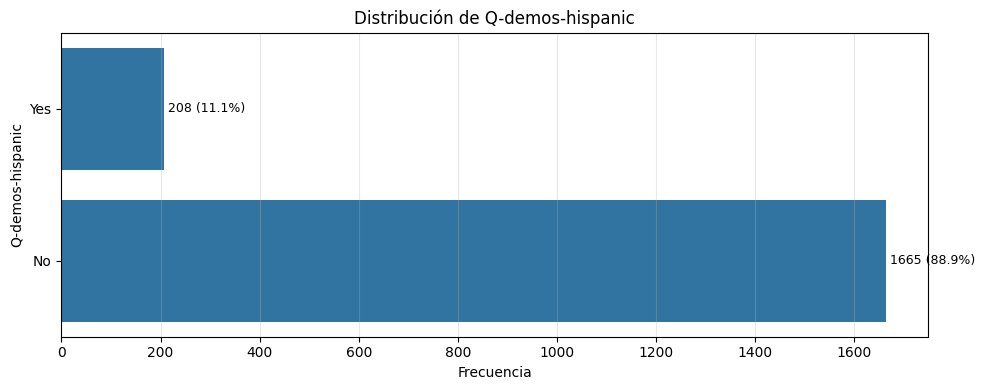

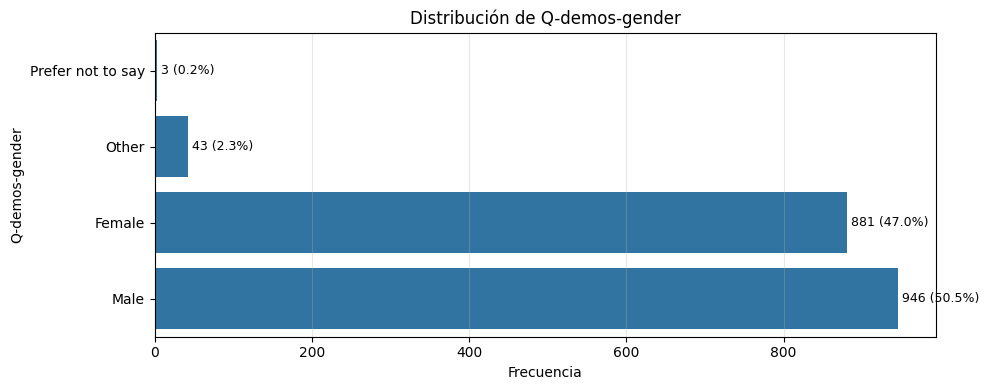

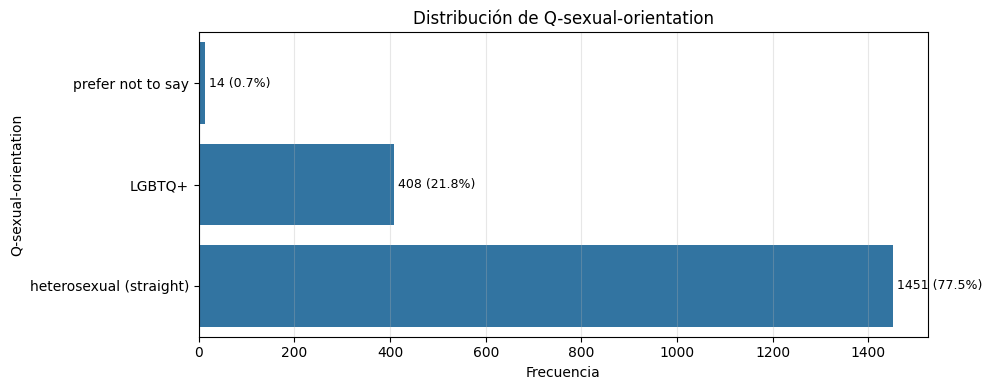

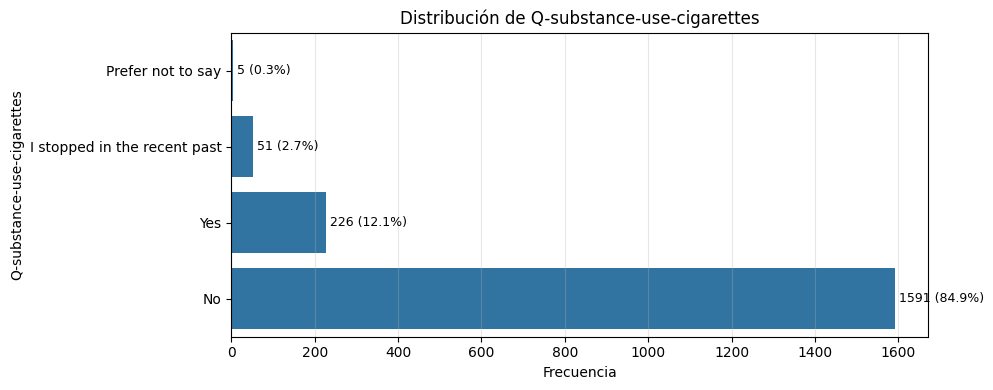

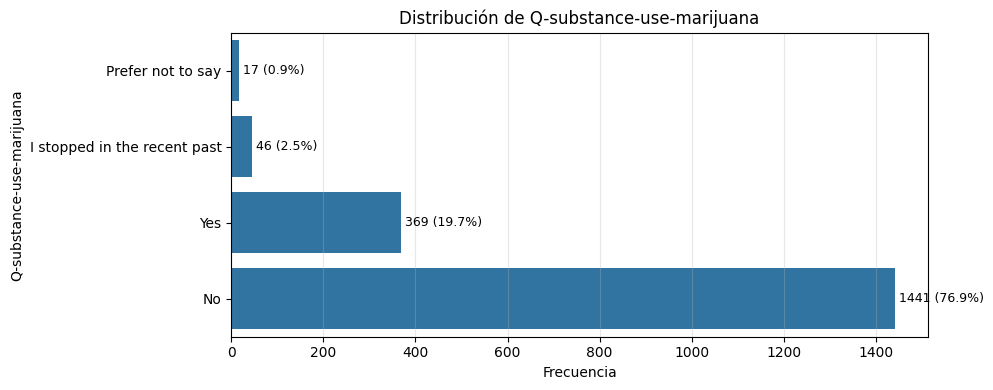

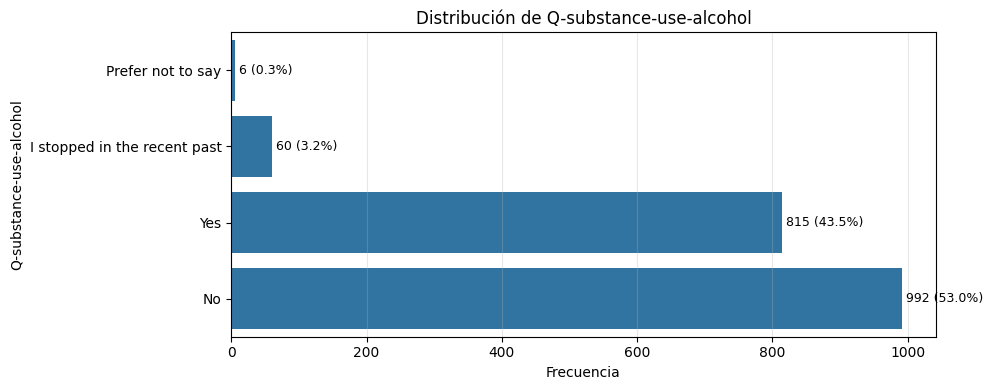

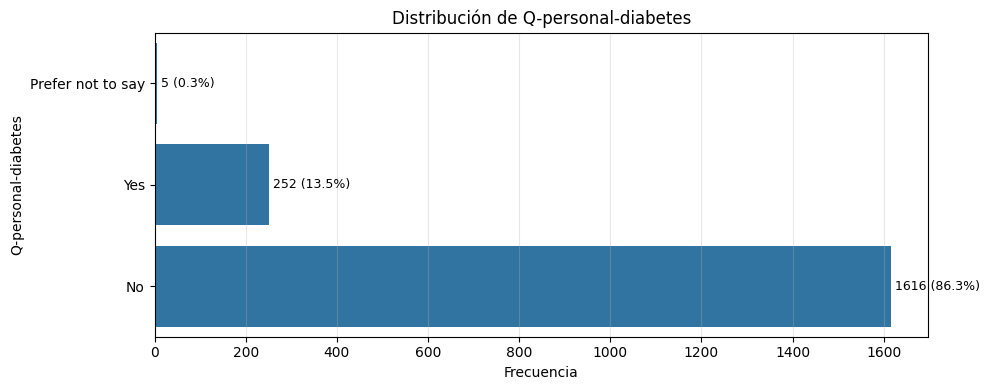

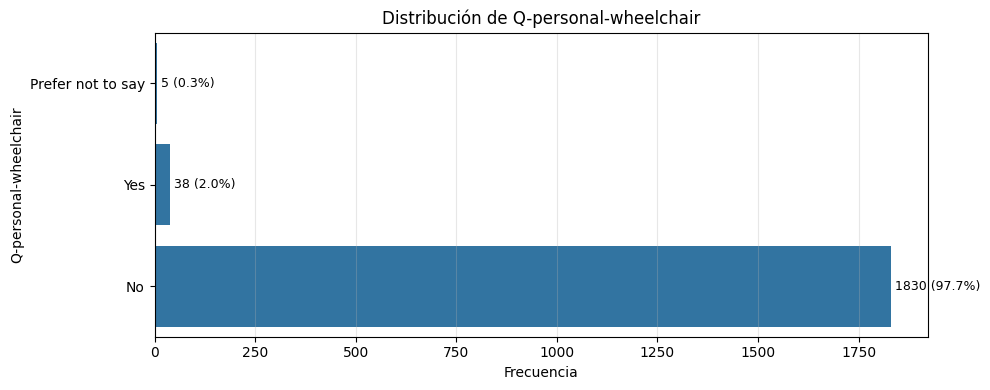

In [217]:
nominal_cols = [
    "Q-demos-hispanic",
    "Q-demos-gender",
    "Q-sexual-orientation",
    "Q-substance-use-cigarettes",
    "Q-substance-use-marijuana",
    "Q-substance-use-alcohol",
    "Q-personal-diabetes",
    "Q-personal-wheelchair"
]

for col in nominal_cols:
    if col in base_clientes_train.columns:
        
        counts = (
            base_clientes_train[col]
            .fillna("Missing")
            .value_counts()
            .sort_values(ascending=True)
        )
        
        plt.figure(figsize=(10, max(4, 0.35 * len(counts))))
        
        ax = sns.barplot(
            x=counts.values,
            y=counts.index,
            orient="h"
        )
        
        total = counts.sum()
        
        for i, value in enumerate(counts.values):
            pct = value / total * 100
            ax.text(
                value,
                i,
                f" {value} ({pct:.1f}%)",
                va="center",
                fontsize=9
            )
        
        plt.title(f"Distribución de {col}")
        plt.xlabel("Frecuencia")
        plt.ylabel(col)
        plt.grid(axis="x", alpha=0.3)
        plt.tight_layout()
        plt.show()

In [218]:
nominal_cols = [
    "Q-demos-hispanic",
    "Q-demos-gender",
    "Q-sexual-orientation",
    "Q-substance-use-cigarettes",
    "Q-substance-use-marijuana",
    "Q-substance-use-alcohol",
    "Q-personal-diabetes",
    "Q-personal-wheelchair"
]

# Define aquí la categoría de referencia para cada variable
reference_levels = {
    "Q-demos-hispanic": "No",
    "Q-demos-gender": "Male",
    "Q-sexual-orientation": "heterosexual (straight)",
    "Q-substance-use-cigarettes": "No",
    "Q-substance-use-marijuana": "No",
    "Q-substance-use-alcohol": "No",
    "Q-personal-diabetes": "No",
    "Q-personal-wheelchair": "No"
}

In [219]:
df_model = df.copy()

dummy_parts = []

for col in nominal_cols:
    if col in df_model.columns:
        
        # Convertir a string y manejar nulos
        s = df_model[col].astype("string").fillna("Missing")
        
        ref = reference_levels[col]
        
        # Todas las categorías observadas
        categories = list(s.dropna().unique())
        
        # Asegurar que la referencia exista
        if ref not in categories:
            print(f"Advertencia: la referencia '{ref}' no aparece en {col}")
            print("Categorías disponibles:", categories)
            continue
        
        # Poner la referencia como primera categoría
        ordered_categories = [ref] + [cat for cat in categories if cat != ref]
        
        s = pd.Categorical(s, categories=ordered_categories, ordered=False)
        
        dummies = pd.get_dummies(
            s,
            prefix=col,
            drop_first=True,
            dtype=int
        )
        
        dummy_parts.append(dummies)

# Unir todas las dummies
nominal_dummies = pd.concat(dummy_parts, axis=1)

# Quitar columnas nominales originales y pegar dummies
df_model = df_model.drop(columns=nominal_cols)
df_model = pd.concat([df_model.reset_index(drop=True), nominal_dummies.reset_index(drop=True)], axis=1)

df_model.head()

,Survey ResponseID,recency_days,frequency,monetary,dollar_avg_12m,dollar_top1_12m,dollar_avg12_top1_ratio,Q-amazon-use-how-oft,Q-demos-age,Q-demos-education,Q-demos-income,Q-amazon-use-howmany,Q-amazon-use-hh-size,race_white_or_caucasian,race_asian,race_black_or_african_american,race_other,race_american_indian_native_american_or_alaska_native,race_native_hawaiian_or_other_pacific_islander,n_states,Q-demos-hispanic_Yes,Q-demos-gender_Female,Q-demos-gender_Other,Q-demos-gender_Prefer not to say,Q-sexual-orientation_LGBTQ+,Q-sexual-orientation_prefer not to say,Q-substance-use-cigarettes_Yes,Q-substance-use-cigarettes_I stopped in the recent past,Q-substance-use-cigarettes_Prefer not to say,Q-substance-use-marijuana_Yes,Q-substance-use-marijuana_I stopped in the recent past,Q-substance-use-marijuana_Prefer not to say,Q-substance-use-alcohol_Yes,Q-substance-use-alcohol_I stopped in the recent past,Q-substance-use-alcohol_Prefer not to say,Q-personal-diabetes_Yes,Q-personal-diabetes_Prefer not to say,Q-personal-wheelchair_Yes,Q-personal-wheelchair_Prefer not to say
0,R_01vNIayewjIIKMF,248,9,270.91,89.99,89.99,1.00000,0,2,2.0,1.0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,R_037XK72IZBJyF69,146,5,57.45,9.99,9.99,1.00000,0,4,2.0,1.0,0,1,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2,R_03aEbghUILs9NxD,23,1,10.99,10.99,10.99,1.00000,0,2,2.0,2.0,0,3,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,R_06d9ULxrBmkwSTn,215,7,159.46,65.44,119.97,0.54547,0,3,2.0,4.0,0,2,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,R_08uYA7fb4unHGkF,48,1,293.00,293.00,293.00,1.00000,1,1,1.0,1.0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [220]:
df_model.columns

Index(['Survey ResponseID', 'recency_days', 'frequency', 'monetary',
       'dollar_avg_12m', 'dollar_top1_12m', 'dollar_avg12_top1_ratio',
       'Q-amazon-use-how-oft', 'Q-demos-age', 'Q-demos-education',
       'Q-demos-income', 'Q-amazon-use-howmany', 'Q-amazon-use-hh-size',
       'race_white_or_caucasian', 'race_asian',
       'race_black_or_african_american', 'race_other',
       'race_american_indian_native_american_or_alaska_native',
       'race_native_hawaiian_or_other_pacific_islander', 'n_states',
       'Q-demos-hispanic_Yes', 'Q-demos-gender_Female', 'Q-demos-gender_Other',
       'Q-demos-gender_Prefer not to say', 'Q-sexual-orientation_LGBTQ+',
       'Q-sexual-orientation_prefer not to say',
       'Q-substance-use-cigarettes_Yes',
       'Q-substance-use-cigarettes_I stopped in the recent past',
       'Q-substance-use-cigarettes_Prefer not to say',
       'Q-substance-use-marijuana_Yes',
       'Q-substance-use-marijuana_I stopped in the recent past',
       'Q-subs

In [221]:
dummy_cols = [c for c in df_model.columns if any(c.startswith(col + "_") for col in nominal_cols)]
dummy_cols

['Q-demos-hispanic_Yes',
 'Q-demos-gender_Female',
 'Q-demos-gender_Other',
 'Q-demos-gender_Prefer not to say',
 'Q-sexual-orientation_LGBTQ+',
 'Q-sexual-orientation_prefer not to say',
 'Q-substance-use-cigarettes_Yes',
 'Q-substance-use-cigarettes_I stopped in the recent past',
 'Q-substance-use-cigarettes_Prefer not to say',
 'Q-substance-use-marijuana_Yes',
 'Q-substance-use-marijuana_I stopped in the recent past',
 'Q-substance-use-marijuana_Prefer not to say',
 'Q-substance-use-alcohol_Yes',
 'Q-substance-use-alcohol_I stopped in the recent past',
 'Q-substance-use-alcohol_Prefer not to say',
 'Q-personal-diabetes_Yes',
 'Q-personal-diabetes_Prefer not to say',
 'Q-personal-wheelchair_Yes',
 'Q-personal-wheelchair_Prefer not to say']

In [222]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

df_model.head(5)

,Survey ResponseID,recency_days,frequency,monetary,dollar_avg_12m,dollar_top1_12m,dollar_avg12_top1_ratio,Q-amazon-use-how-oft,Q-demos-age,Q-demos-education,Q-demos-income,Q-amazon-use-howmany,Q-amazon-use-hh-size,race_white_or_caucasian,race_asian,race_black_or_african_american,race_other,race_american_indian_native_american_or_alaska_native,race_native_hawaiian_or_other_pacific_islander,n_states,Q-demos-hispanic_Yes,Q-demos-gender_Female,Q-demos-gender_Other,Q-demos-gender_Prefer not to say,Q-sexual-orientation_LGBTQ+,Q-sexual-orientation_prefer not to say,Q-substance-use-cigarettes_Yes,Q-substance-use-cigarettes_I stopped in the recent past,Q-substance-use-cigarettes_Prefer not to say,Q-substance-use-marijuana_Yes,Q-substance-use-marijuana_I stopped in the recent past,Q-substance-use-marijuana_Prefer not to say,Q-substance-use-alcohol_Yes,Q-substance-use-alcohol_I stopped in the recent past,Q-substance-use-alcohol_Prefer not to say,Q-personal-diabetes_Yes,Q-personal-diabetes_Prefer not to say,Q-personal-wheelchair_Yes,Q-personal-wheelchair_Prefer not to say
0,R_01vNIayewjIIKMF,248,9,270.91,89.99,89.99,1.00000,0,2,2.0,1.0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,R_037XK72IZBJyF69,146,5,57.45,9.99,9.99,1.00000,0,4,2.0,1.0,0,1,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2,R_03aEbghUILs9NxD,23,1,10.99,10.99,10.99,1.00000,0,2,2.0,2.0,0,3,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,R_06d9ULxrBmkwSTn,215,7,159.46,65.44,119.97,0.54547,0,3,2.0,4.0,0,2,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,R_08uYA7fb4unHGkF,48,1,293.00,293.00,293.00,1.00000,1,1,1.0,1.0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [223]:
cols_12m = [
    "dollar_avg_12m",
    "dollar_top1_12m",
    "dollar_avg12_top1_ratio"
]

df_model[cols_12m] = df_model[cols_12m].fillna(0)

In [224]:
df_model.isnull().sum()

Survey ResponseID                                           0
recency_days                                                0
frequency                                                   0
monetary                                                    0
dollar_avg_12m                                              0
dollar_top1_12m                                             0
dollar_avg12_top1_ratio                                     0
Q-amazon-use-how-oft                                        0
Q-demos-age                                                 0
Q-demos-education                                          13
Q-demos-income                                             21
Q-amazon-use-howmany                                        0
Q-amazon-use-hh-size                                        0
race_white_or_caucasian                                     0
race_asian                                                  0
race_black_or_african_american                              0
race_oth

## Modelo 1: Todas las variables

In [225]:
######################################################################################
# ShoW empírico para train
######################################################################################

train_ids = pd.read_csv("train_ids.csv")
train_ids["response_id"] = train_ids["response_id"].astype(str)

ids_train = train_ids["response_id"].unique()

purchases_T2_train = purchases_T2[
    purchases_T2["Survey ResponseID"].isin(ids_train)
].copy()

sow_train_aux = (
    purchases_T2_train
    .groupby("Survey ResponseID")
    .agg(
        amount_samsung=(
            "amount",
            lambda x: x[purchases_T2_train.loc[x.index, "is_samsung"]].sum()
        ),
        amount_total=("amount", "sum")
    )
    .reset_index()
)

sow_train = (
    pd.DataFrame({"Survey ResponseID": ids_train})
    .merge(sow_train_aux, on="Survey ResponseID", how="left")
)

sow_train[["amount_samsung", "amount_total"]] = (
    sow_train[["amount_samsung", "amount_total"]].fillna(0)
)

sow_train["sow_empirical"] = np.where(
    sow_train["amount_total"] > 0,
    sow_train["amount_samsung"] / sow_train["amount_total"],
    0
)

print("IDs train:", len(ids_train))
print("Filas sow_train:", sow_train.shape[0])
print("ShoW entre 0 y 1:", sow_train["sow_empirical"].between(0, 1).all())
print(sow_train["sow_empirical"].describe())

IDs train: 1876
Filas sow_train: 1876
ShoW entre 0 y 1: True
count    1876.000000
mean        0.065300
std         0.134536
min         0.000000
25%         0.000000
50%         0.011770
75%         0.068380
max         1.000000
Name: sow_empirical, dtype: float64


In [226]:
sow_train

,Survey ResponseID,amount_samsung,amount_total,sow_empirical
0,R_2DYNUe9cQV68GxO,325.71,5486.44,0.059366
1,R_1GIfjocF2dRzyeH,0.00,1514.20,0.000000
2,R_2dWMLgcNB9pmhBe,0.00,103.22,0.000000
3,R_32WvdLjYpicai6o,0.00,79.94,0.000000
4,R_3Jxiicg67etW2yt,22.99,1264.26,0.018185
...,...,...,...,...
1871,R_1pSEkm1mOy4kpKO,0.00,93.30,0.000000
1872,R_2wS2aXKSVboHglr,59.99,1755.25,0.034177
1873,R_1JJ9dsXDfWNb4HX,0.00,27.38,0.000000
1874,R_1GVsIStj8gTkbIE,0.00,449.88,0.000000


In [227]:
# ============================================================
# 10. Pipeline de preprocesamiento sin leakage
# ============================================================

df_model["Survey ResponseID"] = df_model["Survey ResponseID"].astype(str)
sow_train["Survey ResponseID"] = sow_train["Survey ResponseID"].astype(str)

train_model = df_model.merge(
    sow_train[["Survey ResponseID", "sow_empirical"]],
    on="Survey ResponseID",
    how="inner"
)

X_train = train_model.drop(
    columns=["Survey ResponseID", "sow_empirical"],
    errors="ignore"
)

y_train = train_model["sow_empirical"]

print(X_train.shape)
print(y_train.shape)
print(train_model["sow_empirical"].between(0, 1).all())

(1873, 38)
(1873,)
True


In [228]:
class TukeyWinsorizer(BaseEstimator, TransformerMixin):
    def __init__(self, k=3):
        self.k = k
        self.caps_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()

        q1 = X.quantile(0.25)
        q3 = X.quantile(0.75)
        iqr = q3 - q1

        self.caps_ = q3 + self.k * iqr
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        return X.clip(upper=self.caps_, axis=1)

In [229]:
X_train.head(10)

,recency_days,frequency,monetary,dollar_avg_12m,dollar_top1_12m,dollar_avg12_top1_ratio,Q-amazon-use-how-oft,Q-demos-age,Q-demos-education,Q-demos-income,Q-amazon-use-howmany,Q-amazon-use-hh-size,race_white_or_caucasian,race_asian,race_black_or_african_american,race_other,race_american_indian_native_american_or_alaska_native,race_native_hawaiian_or_other_pacific_islander,n_states,Q-demos-hispanic_Yes,Q-demos-gender_Female,Q-demos-gender_Other,Q-demos-gender_Prefer not to say,Q-sexual-orientation_LGBTQ+,Q-sexual-orientation_prefer not to say,Q-substance-use-cigarettes_Yes,Q-substance-use-cigarettes_I stopped in the recent past,Q-substance-use-cigarettes_Prefer not to say,Q-substance-use-marijuana_Yes,Q-substance-use-marijuana_I stopped in the recent past,Q-substance-use-marijuana_Prefer not to say,Q-substance-use-alcohol_Yes,Q-substance-use-alcohol_I stopped in the recent past,Q-substance-use-alcohol_Prefer not to say,Q-personal-diabetes_Yes,Q-personal-diabetes_Prefer not to say,Q-personal-wheelchair_Yes,Q-personal-wheelchair_Prefer not to say
0,248,9,270.91,89.99,89.99,1.000000,0,2,2.0,1.0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,146,5,57.45,9.99,9.99,1.000000,0,4,2.0,1.0,0,1,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2,23,1,10.99,10.99,10.99,1.000000,0,2,2.0,2.0,0,3,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,215,7,159.46,65.44,119.97,0.545470,0,3,2.0,4.0,0,2,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,48,1,293.00,293.00,293.00,1.000000,1,1,1.0,1.0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,367,5,61.95,0.00,0.00,0.000000,0,4,1.0,0.0,0,0,1,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,528,6,81.46,0.00,0.00,0.000000,0,2,2.0,2.0,0,3,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
7,615,1,14.97,0.00,0.00,0.000000,0,2,1.0,3.0,1,2,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0
8,337,3,30.97,9.99,9.99,1.000000,0,2,1.0,1.0,0,1,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0
9,59,10,568.81,106.17,279.99,0.379192,2,2,1.0,1.0,1,1,1,0,0,0,0,0,2,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0


In [230]:
X_train.columns

Index(['recency_days', 'frequency', 'monetary', 'dollar_avg_12m',
       'dollar_top1_12m', 'dollar_avg12_top1_ratio', 'Q-amazon-use-how-oft',
       'Q-demos-age', 'Q-demos-education', 'Q-demos-income',
       'Q-amazon-use-howmany', 'Q-amazon-use-hh-size',
       'race_white_or_caucasian', 'race_asian',
       'race_black_or_african_american', 'race_other',
       'race_american_indian_native_american_or_alaska_native',
       'race_native_hawaiian_or_other_pacific_islander', 'n_states',
       'Q-demos-hispanic_Yes', 'Q-demos-gender_Female', 'Q-demos-gender_Other',
       'Q-demos-gender_Prefer not to say', 'Q-sexual-orientation_LGBTQ+',
       'Q-sexual-orientation_prefer not to say',
       'Q-substance-use-cigarettes_Yes',
       'Q-substance-use-cigarettes_I stopped in the recent past',
       'Q-substance-use-cigarettes_Prefer not to say',
       'Q-substance-use-marijuana_Yes',
       'Q-substance-use-marijuana_I stopped in the recent past',
       'Q-substance-use-marijuana_P

### Pipeline

In [231]:
# ============================================================
# 10. Pipeline de preprocesamiento sin leakage
# ============================================================
numeric_cols = [
    "recency_days",
    "frequency",
    "monetary",
    "dollar_avg_12m",
    "dollar_top1_12m",
    "dollar_avg12_top1_ratio",
    "n_states"
]

impute_cols = ["Q-demos-education",
               "Q-demos-income"
]

cat_cols = [col for col in X_train.columns if col not in numeric_cols + impute_cols]

numeric_pipeline = Pipeline(steps=[
    ("winsor", TukeyWinsorizer(k=3.0)),
    ("scaler", StandardScaler())
])

imputation_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_cols),
        ("impute", imputation_pipeline, impute_cols),
        ("cat", "passthrough", cat_cols)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)


In [232]:
# ============================================================
# 11. Modelo XGBRegressor acotado: objective='reg:logistic'
# ============================================================
xgb_show = XGBRegressor(
    objective="reg:logistic",
    eval_metric="mae",
    tree_method="hist",
    max_delta_step = 1,
    
    n_estimators=10000,
    learning_rate=0.1,#0.002, 0.005, 0.01, 0.02, 0.05,0.1,0.2,0.5
    
    max_depth=5,#1,2,3,4,5,6,7

    min_child_weight=5,
    subsample=0.9,
    colsample_bytree=1.0,
    reg_lambda=1,
    reg_alpha=0.1,
    random_state=123,
    n_jobs=-1
)

model_xgb_show = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("xgb", xgb_show)
])

model_xgb_show.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('xgb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('impute', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


In [233]:
y_pred_train = model_xgb_show.predict(X_train)

### Validacion cruzada estratificada

In [234]:
# ============================================================
# Validación cruzada estratificada por bins de ShoW
# ============================================================

# ------------------------------------------------------------
# 1. Verificar que y_train esté en [0, 1]
# ------------------------------------------------------------

y_train = y_train.astype(float)

print("Mínimo y_train:", y_train.min())
print("Máximo y_train:", y_train.max())
print("y_train entre 0 y 1:", y_train.between(0, 1).all())

if not y_train.between(0, 1).all():
    raise ValueError("y_train debe estar en el intervalo [0, 1] para objective='reg:logistic'.")

# ------------------------------------------------------------
# 2. Crear bins para estratificación
# ------------------------------------------------------------

# Usar esta versión si algún bin queda con muy pocos casos
y_bins = pd.cut(
    y_train,
    bins=[-0.001, 0, 0.05, 1.00],
    labels=["0", "0-0.05", "0.05-1.00"],
    include_lowest=True
)

print("Distribución de bins ajustados:")
print(y_bins.value_counts(dropna=False).sort_index())

Mínimo y_train: 0.0
Máximo y_train: 1.0
y_train entre 0 y 1: True
Distribución de bins ajustados:
sow_empirical
0            820
0-0.05       490
0.05-1.00    563
Name: count, dtype: int64


In [235]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=123
)

cv_splits = list(cv.split(X_train, y_bins))

In [236]:
for i, (_, val_idx) in enumerate(cv_splits, start=1):
    print(f"\nFold {i}")
    print(y_bins.iloc[val_idx].value_counts().sort_index())


Fold 1
sow_empirical
0            164
0-0.05        98
0.05-1.00    113
Name: count, dtype: int64

Fold 2
sow_empirical
0            164
0-0.05        98
0.05-1.00    113
Name: count, dtype: int64

Fold 3
sow_empirical
0            164
0-0.05        98
0.05-1.00    113
Name: count, dtype: int64

Fold 4
sow_empirical
0            164
0-0.05        98
0.05-1.00    112
Name: count, dtype: int64

Fold 5
sow_empirical
0            164
0-0.05        98
0.05-1.00    112
Name: count, dtype: int64


### Mejores hiperparametros

In [237]:
# ------------------------------------------------------------
# Definir modelo base XGBoost acotado
# ------------------------------------------------------------

xgb_show = XGBRegressor(
    objective="reg:logistic",
    eval_metric="mae",
    tree_method="hist",
    random_state=123,
    n_jobs=-1,
    max_delta_step = 1
)

model_xgb_show = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("xgb", xgb_show)
])

# ------------------------------------------------------------
# Hiperparámetros a evaluar
# ------------------------------------------------------------

param_distributions = {
    "xgb__n_estimators": [100,200, 500, 1000, 1500,2000, 2500, 3000, 5000, 10000],
    "xgb__learning_rate": [0.002, 0.005, 0.01, 0.02, 0.15, 0.1, 0.2, 0.5],
    "xgb__max_depth": [1, 2, 3, 4, 5],
    "xgb__min_child_weight": [1, 3, 5, 10],
    "xgb__subsample": [0.7, 0.8, 0.9, 1.0],
    "xgb__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "xgb__reg_lambda": [1, 3, 5, 10],
    "xgb__reg_alpha": [0, 0.01, 0.1, 1]
}

# ------------------------------------------------------------
# 6. RandomizedSearchCV con MAE y CV estratificada
# ------------------------------------------------------------

search_xgb_show = RandomizedSearchCV(
    estimator=model_xgb_show,
    param_distributions=param_distributions,
    n_iter=40,
    scoring="neg_mean_absolute_error",
    cv=cv_splits,
    random_state=123,
    n_jobs=-1,
    verbose=1,
    refit=True
)

search_xgb_show.fit(X_train, y_train)

print("Mejores hiperparámetros:")
print(search_xgb_show.best_params_)

print("Mejor MAE CV:")
print(-search_xgb_show.best_score_)

# ------------------------------------------------------------
# 7. Modelo final entrenado con todo el train
# ------------------------------------------------------------

best_model_xgb_show = search_xgb_show.best_estimator_

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Mejores hiperparámetros:
{'xgb__subsample': 0.9, 'xgb__reg_lambda': 1, 'xgb__reg_alpha': 0.1, 'xgb__n_estimators': 10000, 'xgb__min_child_weight': 1, 'xgb__max_depth': 5, 'xgb__learning_rate': 0.1, 'xgb__colsample_bytree': 1.0}
Mejor MAE CV:
0.07410738636392122


In [238]:
len(y_train)

1873

### X_test

In [239]:
# ============================================================
# Construir base_test usando test_ids.csv
# ============================================================

test_ids = pd.read_csv("test_ids.csv")["response_id"].astype(str).drop_duplicates()

base["Survey ResponseID"] = base["Survey ResponseID"].astype(str)

base_test = base[
    base["Survey ResponseID"].isin(test_ids)
].copy()

print("IDs test:", len(test_ids))
print("Filas base_test:", base_test.shape)
print("Clientes únicos base_test:", base_test["Survey ResponseID"].nunique())

base_test.head()

IDs test: 469
Filas base_test: (468, 7)
Clientes únicos base_test: 468


,Survey ResponseID,recency_days,frequency,monetary,dollar_avg_12m,dollar_top1_12m,dollar_avg12_top1_ratio
27,R_0lHgeveolyaJhND,277,3,218.34,150.360,150.36,1.000000
29,R_0oBzc3D8v94kGiZ,186,4,52.85,10.990,10.99,1.000000
35,R_10MFxyIhsIDW0nP,127,3,81.76,23.885,23.98,0.996038
53,R_11cp7qScmrrE4EF,195,7,355.34,314.980,314.98,1.000000
54,R_11gymhOPZz4baOa,24,1,11.95,11.950,11.95,1.000000


In [240]:
ordinal_cols = [
    "Q-amazon-use-how-oft",
    "Q-demos-age",
    "Q-demos-education",
    "Q-demos-income",
    "Q-amazon-use-howmany",
    "Q-amazon-use-hh-size"
]

nominal_cols = [
    "Q-demos-hispanic",
    "Q-demos-gender",
    "Q-sexual-orientation",
    "Q-substance-use-cigarettes",
    "Q-substance-use-marijuana",
    "Q-substance-use-alcohol",
    "Q-personal-diabetes",
    "Q-personal-wheelchair"
]

cat_cols = ordinal_cols + nominal_cols

# Dejar solo columnas que existan
cat_cols = [col for col in cat_cols if col in survey.columns]
ordinal_cols = [col for col in ordinal_cols if col in survey.columns]
nominal_cols = [col for col in nominal_cols if col in survey.columns]

# Unir base transaccional con encuesta
base_clientes_test = base_test.merge(
    survey[["Survey ResponseID"] + cat_cols],
    on="Survey ResponseID",
    how="left"
)

# Verificar una fila por cliente
print(base_clientes_test.shape)
print(base_clientes_test["Survey ResponseID"].nunique())
print(base_clientes_test["Survey ResponseID"].duplicated().sum())

(468, 21)
468
0


In [241]:
base_clientes_test.isnull().sum()

Survey ResponseID               0
recency_days                    0
frequency                       0
monetary                        0
dollar_avg_12m                166
dollar_top1_12m               166
dollar_avg12_top1_ratio       166
Q-amazon-use-how-oft            0
Q-demos-age                     0
Q-demos-education               0
Q-demos-income                  0
Q-amazon-use-howmany            0
Q-amazon-use-hh-size            0
Q-demos-hispanic                0
Q-demos-gender                  0
Q-sexual-orientation            0
Q-substance-use-cigarettes      0
Q-substance-use-marijuana       0
Q-substance-use-alcohol         0
Q-personal-diabetes             0
Q-personal-wheelchair           0
dtype: int64

In [242]:
cols_12m = [
    "dollar_avg_12m",
    "dollar_top1_12m",
    "dollar_avg12_top1_ratio"
]

base_clientes_test[cols_12m] = base_clientes_test[cols_12m].fillna(0)

In [243]:
base_clientes_test.head()

,Survey ResponseID,recency_days,frequency,monetary,dollar_avg_12m,dollar_top1_12m,dollar_avg12_top1_ratio,Q-amazon-use-how-oft,Q-demos-age,Q-demos-education,Q-demos-income,Q-amazon-use-howmany,Q-amazon-use-hh-size,Q-demos-hispanic,Q-demos-gender,Q-sexual-orientation,Q-substance-use-cigarettes,Q-substance-use-marijuana,Q-substance-use-alcohol,Q-personal-diabetes,Q-personal-wheelchair
0,R_0lHgeveolyaJhND,277,3,218.34,150.360,150.36,1.000000,5 - 10 times per month,25 - 34 years,High school diploma or GED,"$25,000 - $49,999",1 (just me!),1 (just me!),No,Male,heterosexual (straight),Yes,No,No,Yes,No
1,R_0oBzc3D8v94kGiZ,186,4,52.85,10.990,10.99,1.000000,Less than 5 times per month,35 - 44 years,"Graduate or professional degree (MA, MS, MBA, PhD, JD, MD, DDS, etc)","Less than $25,000",3,3,Yes,Male,heterosexual (straight),Yes,No,Yes,No,No
2,R_10MFxyIhsIDW0nP,127,3,81.76,23.885,23.98,0.996038,Less than 5 times per month,55 - 64 years,Bachelor's degree,"$100,000 - $149,999",1 (just me!),1 (just me!),No,Male,heterosexual (straight),No,No,No,No,No
3,R_11cp7qScmrrE4EF,195,7,355.34,314.980,314.98,1.000000,Less than 5 times per month,45 - 54 years,Bachelor's degree,"$25,000 - $49,999",1 (just me!),3,No,Female,LGBTQ+,No,No,No,Yes,Yes
4,R_11gymhOPZz4baOa,24,1,11.95,11.950,11.95,1.000000,5 - 10 times per month,35 - 44 years,Bachelor's degree,"$50,000 - $74,999",2,4+,No,Female,LGBTQ+,No,No,Yes,No,No


In [244]:
# ------------------------------------------------------------
# 4. Dejar una sola fila por cliente en survey
# ------------------------------------------------------------

survey_race = (
    survey[["Survey ResponseID"] + race_cols]
    .drop_duplicates(subset="Survey ResponseID")
)

# ------------------------------------------------------------
# 5. Unir con base_clientes_train
# ------------------------------------------------------------

base_clientes_test = base_clientes_test.merge(
    survey_race,
    on="Survey ResponseID",
    how="left"
)

# Reemplazar NA por 0 en las dummies de raza
base_clientes_test[race_cols] = base_clientes_test[race_cols].fillna(0).astype(int)

# Verificar resultado
print(base_clientes_test.shape)
print(base_clientes_test[race_cols].head())

(468, 27)
   race_white_or_caucasian  race_asian  race_black_or_african_american  \
0                        1           0                               0   
1                        1           0                               0   
2                        1           0                               0   
3                        1           0                               0   
4                        1           0                               0   

   race_other  race_american_indian_native_american_or_alaska_native  \
0           0                                                      0   
1           0                                                      0   
2           0                                                      0   
3           0                                                      0   
4           0                                                      0   

   race_native_hawaiian_or_other_pacific_islander  
0                                               0  
1       

In [245]:
# ------------------------------------------------------------
# n_states SOLO para clientes de base_clientes_test
# ------------------------------------------------------------

ids_test = base_clientes_test["Survey ResponseID"].astype(str).unique()

purchases_T1_test = purchases_T1[
    purchases_T1["Survey ResponseID"].astype(str).isin(ids_test)
].copy()

# Limpiar Shipping Address State
purchases_T1_test["shipping_state_clean"] = (
    purchases_T1_test["Shipping Address State"]
    .astype("string")
    .str.strip()
    .str.upper()
)

# Reemplazar nulos o vacíos por DIGITAL/LOCKER
purchases_T1_test["shipping_state_clean"] = (
    purchases_T1_test["shipping_state_clean"]
    .replace(["", "NAN", "NONE", "<NA>"], pd.NA)
    .fillna("DIGITAL/LOCKER")
)

# Contar estados distintos por cliente, excluyendo DIGITAL/LOCKER
state_summ_test = (
    purchases_T1_test
    .assign(
        state_for_count=lambda df: df["shipping_state_clean"].where(
            df["shipping_state_clean"] != "DIGITAL/LOCKER",
            pd.NA
        )
    )
    .groupby("Survey ResponseID")
    .agg(
        n_states=("state_for_count", "nunique")
    )
    .reset_index()
)

state_summ_test["Survey ResponseID"] = state_summ_test["Survey ResponseID"].astype(str)

In [246]:
# Asegurar mismo tipo de ID
base_clientes_test["Survey ResponseID"] = base_clientes_test["Survey ResponseID"].astype(str)

# Evitar duplicados si ya existía n_states
base_clientes_test = base_clientes_test.drop(
    columns=[c for c in ["n_states"] if c in base_clientes_test.columns]
)

# Merge con n_states
base_clientes_test = base_clientes_test.merge(
    state_summ_test,
    on="Survey ResponseID",
    how="left"
)

# Si algún cliente no aparece en purchases_T1_test, poner 0
base_clientes_test["n_states"] = (
    base_clientes_test["n_states"]
    .fillna(0)
    .astype(int)
)

base_clientes_test[["Survey ResponseID", "n_states"]].head()

,Survey ResponseID,n_states
0,R_0lHgeveolyaJhND,1
1,R_0oBzc3D8v94kGiZ,1
2,R_10MFxyIhsIDW0nP,1
3,R_11cp7qScmrrE4EF,1
4,R_11gymhOPZz4baOa,1


In [247]:
df = base_clientes_test.copy()

ordinal_mappings = {
    "Q-demos-education": {
        "Some high school or less": 0,
        "High school diploma or GED": 1,
        "Bachelor's degree": 2,
        "Graduate or professional degree (MA, MS, MBA, PhD, JD, MD, DDS, etc)": 3,
        "Prefer not to say": np.nan
    },

    "Q-demos-income": {
        "Less than $25,000": 0,
        "$25,000 - $49,999": 1,
        "$50,000 - $74,999": 2,
        "$75,000 - $99,999": 3,
        "$100,000 - $149,999": 4,
        "$150,000 or more": 5,
        "Prefer not to say": np.nan
    },

    "Q-amazon-use-how-oft": {
        "Less than 5 times per month": 0,
        "5 - 10 times per month": 1,
        "More than 10 times per month": 2
    },

    "Q-amazon-use-howmany": {
        "1 (just me!)": 0,
        "2": 1,
        "3": 2,
        "4+": 3
    },

    "Q-demos-age": {
        "18 - 24 years": 0,
        "25 - 34 years": 1,
        "35 - 44 years": 2,
        "45 - 54 years": 3,
        "55 - 64 years": 4,
        "65 and older": 5
    },

    "Q-amazon-use-hh-size": {
        "1 (just me!)": 0,
        "2": 1,
        "3": 2,
        "4+": 3
    }
}

for col, mapping in ordinal_mappings.items():
    if col in df.columns:
        df[col] = df[col].map(mapping)
        print(f"Convertida ordinal: {col}")

Convertida ordinal: Q-demos-education
Convertida ordinal: Q-demos-income
Convertida ordinal: Q-amazon-use-how-oft
Convertida ordinal: Q-amazon-use-howmany
Convertida ordinal: Q-demos-age
Convertida ordinal: Q-amazon-use-hh-size


In [248]:
nominal_cols = [
    "Q-demos-hispanic",
    "Q-demos-gender",
    "Q-sexual-orientation",
    "Q-substance-use-cigarettes",
    "Q-substance-use-marijuana",
    "Q-substance-use-alcohol",
    "Q-personal-diabetes",
    "Q-personal-wheelchair"
]

# Define aquí la categoría de referencia para cada variable
reference_levels = {
    "Q-demos-hispanic": "No",
    "Q-demos-gender": "Male",
    "Q-sexual-orientation": "heterosexual (straight)",
    "Q-substance-use-cigarettes": "No",
    "Q-substance-use-marijuana": "No",
    "Q-substance-use-alcohol": "No",
    "Q-personal-diabetes": "No",
    "Q-personal-wheelchair": "No"
}

In [249]:
df_model = df.copy()

dummy_parts = []

for col in nominal_cols:
    if col in df_model.columns:
        
        # Convertir a string y manejar nulos
        s = df_model[col].astype("string").fillna("Missing")
        
        ref = reference_levels[col]
        
        # Todas las categorías observadas
        categories = list(s.dropna().unique())
        
        # Asegurar que la referencia exista
        if ref not in categories:
            print(f"Advertencia: la referencia '{ref}' no aparece en {col}")
            print("Categorías disponibles:", categories)
            continue
        
        # Poner la referencia como primera categoría
        ordered_categories = [ref] + [cat for cat in categories if cat != ref]
        
        s = pd.Categorical(s, categories=ordered_categories, ordered=False)
        
        dummies = pd.get_dummies(
            s,
            prefix=col,
            drop_first=True,
            dtype=int
        )
        
        dummy_parts.append(dummies)

# Unir todas las dummies
nominal_dummies = pd.concat(dummy_parts, axis=1)

# Quitar columnas nominales originales y pegar dummies
df_model = df_model.drop(columns=nominal_cols)
df_model = pd.concat([df_model.reset_index(drop=True), nominal_dummies.reset_index(drop=True)], axis=1)

df_model.head()

,Survey ResponseID,recency_days,frequency,monetary,dollar_avg_12m,dollar_top1_12m,dollar_avg12_top1_ratio,Q-amazon-use-how-oft,Q-demos-age,Q-demos-education,Q-demos-income,Q-amazon-use-howmany,Q-amazon-use-hh-size,race_white_or_caucasian,race_asian,race_black_or_african_american,race_other,race_american_indian_native_american_or_alaska_native,race_native_hawaiian_or_other_pacific_islander,n_states,Q-demos-hispanic_Yes,Q-demos-gender_Female,Q-demos-gender_Other,Q-sexual-orientation_LGBTQ+,Q-sexual-orientation_prefer not to say,Q-substance-use-cigarettes_Yes,Q-substance-use-cigarettes_I stopped in the recent past,Q-substance-use-marijuana_Yes,Q-substance-use-marijuana_I stopped in the recent past,Q-substance-use-marijuana_Prefer not to say,Q-substance-use-alcohol_Yes,Q-substance-use-alcohol_I stopped in the recent past,Q-personal-diabetes_Yes,Q-personal-diabetes_Prefer not to say,Q-personal-wheelchair_Yes
0,R_0lHgeveolyaJhND,277,3,218.34,150.360,150.36,1.000000,1,1,1.0,1.0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0
1,R_0oBzc3D8v94kGiZ,186,4,52.85,10.990,10.99,1.000000,0,2,3.0,0.0,2,2,1,0,0,0,0,0,1,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0
2,R_10MFxyIhsIDW0nP,127,3,81.76,23.885,23.98,0.996038,0,4,2.0,4.0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,R_11cp7qScmrrE4EF,195,7,355.34,314.980,314.98,1.000000,0,3,2.0,1.0,0,2,1,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,1,0,1
4,R_11gymhOPZz4baOa,24,1,11.95,11.950,11.95,1.000000,1,2,2.0,2.0,1,3,1,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0


In [250]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

df_model.head(5)

,Survey ResponseID,recency_days,frequency,monetary,dollar_avg_12m,dollar_top1_12m,dollar_avg12_top1_ratio,Q-amazon-use-how-oft,Q-demos-age,Q-demos-education,Q-demos-income,Q-amazon-use-howmany,Q-amazon-use-hh-size,race_white_or_caucasian,race_asian,race_black_or_african_american,race_other,race_american_indian_native_american_or_alaska_native,race_native_hawaiian_or_other_pacific_islander,n_states,Q-demos-hispanic_Yes,Q-demos-gender_Female,Q-demos-gender_Other,Q-sexual-orientation_LGBTQ+,Q-sexual-orientation_prefer not to say,Q-substance-use-cigarettes_Yes,Q-substance-use-cigarettes_I stopped in the recent past,Q-substance-use-marijuana_Yes,Q-substance-use-marijuana_I stopped in the recent past,Q-substance-use-marijuana_Prefer not to say,Q-substance-use-alcohol_Yes,Q-substance-use-alcohol_I stopped in the recent past,Q-personal-diabetes_Yes,Q-personal-diabetes_Prefer not to say,Q-personal-wheelchair_Yes
0,R_0lHgeveolyaJhND,277,3,218.34,150.360,150.36,1.000000,1,1,1.0,1.0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0
1,R_0oBzc3D8v94kGiZ,186,4,52.85,10.990,10.99,1.000000,0,2,3.0,0.0,2,2,1,0,0,0,0,0,1,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0
2,R_10MFxyIhsIDW0nP,127,3,81.76,23.885,23.98,0.996038,0,4,2.0,4.0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,R_11cp7qScmrrE4EF,195,7,355.34,314.980,314.98,1.000000,0,3,2.0,1.0,0,2,1,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,1,0,1
4,R_11gymhOPZz4baOa,24,1,11.95,11.950,11.95,1.000000,1,2,2.0,2.0,1,3,1,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0


In [251]:
X_test = df_model
X_test_f = X_test.reindex(columns=X_train.columns, fill_value=0)

In [252]:
X_test_prep = preprocessor.transform(X_test_f)

In [253]:
# ============================================================
# Armar y_test desde empirical_sow.xlsx
# ============================================================

ids_emp = pd.read_excel("empirical_sow.xlsx", sheet_name="id")
sow_emp = pd.read_excel("empirical_sow.xlsx", sheet_name="sow")

empirical_sow_test = pd.concat(
    [
        ids_emp.reset_index(drop=True),
        sow_emp.reset_index(drop=True)
    ],
    axis=1
)

empirical_sow_test = empirical_sow_test.rename(
    columns={
        "response_id": "Survey ResponseID",
        "sow": "sow_empirical"
    }
)

empirical_sow_test["Survey ResponseID"] = empirical_sow_test["Survey ResponseID"].astype(str)

In [254]:
test_model = X_test.merge(
    empirical_sow_test[["Survey ResponseID", "sow_empirical"]],
    on="Survey ResponseID",
    how="inner"
)

In [255]:
y_test = test_model["sow_empirical"].astype(float)

### Prueba final

In [256]:
# ============================================================
# 13. Evaluación final en test externo
# ============================================================

y_pred_test = best_model_xgb_show.predict(X_test_f)

mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)

print("MAE test:", mae_test)
print("RMSE test:", rmse_test)
print("R2 test:", r2_test)

print("Predicción mínima:", y_pred_test.min())
print("Predicción máxima:", y_pred_test.max())

MAE test: 0.08945104235933114
RMSE test: 0.1741738383554941
R2 test: -0.16993997857627363
Predicción mínima: 0.0001862318
Predicción máxima: 0.40530652


In [257]:
resultados_xgb_show = pd.DataFrame({
    "y_test": y_test.values,
    "y_pred": y_pred_test
})

resultados_xgb_show["error_abs"] = (
    resultados_xgb_show["y_test"] - resultados_xgb_show["y_pred"]
).abs()

resultados_xgb_show.head()

,y_test,y_pred,error_abs
0,0.0,0.022108,0.022108
1,0.0,0.050718,0.050718
2,0.0,0.021673,0.021673
3,0.0,0.023890,0.023890
4,0.0,0.004722,0.004722


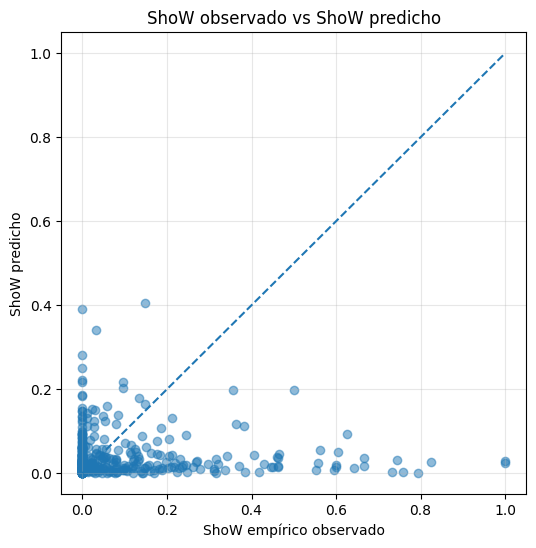

In [258]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_test, alpha=0.5)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("ShoW empírico observado")
plt.ylabel("ShoW predicho")
plt.title("ShoW observado vs ShoW predicho")
plt.grid(alpha=0.3)
plt.show()

In [259]:
print("y_test")
print(y_test.describe())

print("y_pred_test")
print(pd.Series(y_pred_test).describe())

y_test
count    468.000000
mean       0.079373
std        0.161200
min        0.000000
25%        0.000000
50%        0.000000
75%        0.079539
max        1.000000
Name: sow_empirical, dtype: float64
y_pred_test
count    468.000000
mean       0.035581
std        0.051400
min        0.000186
25%        0.006590
50%        0.017749
75%        0.041517
max        0.405307
dtype: float64


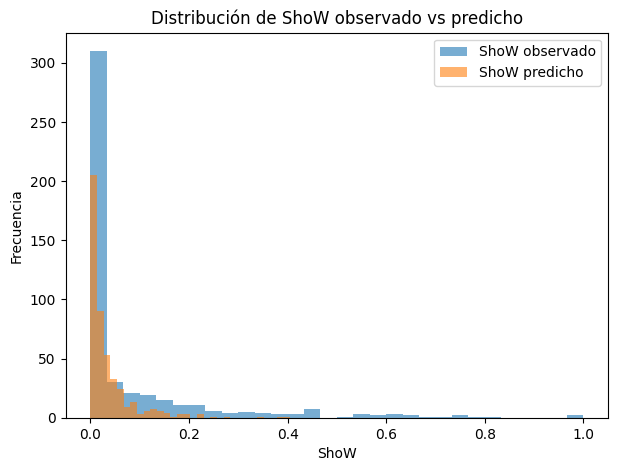

In [260]:
plt.figure(figsize=(7, 5))
plt.hist(y_test, bins=30, alpha=0.6, label="ShoW observado")
plt.hist(y_pred_test, bins=30, alpha=0.6, label="ShoW predicho")
plt.xlabel("ShoW")
plt.ylabel("Frecuencia")
plt.title("Distribución de ShoW observado vs predicho")
plt.legend()
plt.show()

In [261]:
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.08945104235933114
RMSE: 0.1741738383554941


### Comentario

El modelo XGBoost acotado obtuvo un MAE de 0.089 para la predicción del ShoW empírico en el conjunto de prueba. Este valor es inferior al MAE reportado por el modelo Pogit en el apéndice técnico, donde se informa un MAE de 0.320 para la especificación completa y de 0.159 después de la selección de variables. Por tanto, bajo la métrica MAE y sobre el benchmark empírico de ShoW, el modelo XGBoost presenta un menor error absoluto promedio. No obstante, esta comparación debe interpretarse con cautela, dado que XGBoost corresponde a un modelo predictivo supervisado ajustado directamente sobre el ShoW empírico, mientras que el Pogit estima un mecanismo latente de asignación e intensidad bajo observabilidad parcial.

## Modelo 2: feature_importance (type=’gain’ o ’weight’)

Se monitoreó la importancia de variables del modelo XGBoost mediante los criterios gain y weight. El criterio gain cuantifica la contribución promedio de cada predictor a la reducción del error del modelo, mientras que weight contabiliza la frecuencia con la que cada variable fue utilizada en las divisiones de los árboles. En este estudio se privilegió la interpretación basada en gain, dado que refleja de forma más directa el aporte predictivo de cada variable.

In [ ]:
# ============================================================
# Feature importance para tu modelo XGBoost
# ============================================================

# Extraer partes entrenadas del pipeline
preprocessor_fit = model_xgb_show.named_steps["preprocessor"]
xgb_model = model_xgb_show.named_steps["xgb"]

# Nombres de variables en el mismo orden del ColumnTransformer
feature_names = []

for name, transformer, cols in preprocessor_fit.transformers_:
    if name == "remainder":
        continue
    feature_names.extend(list(cols))

# Verificación
X_train_prep = preprocessor_fit.transform(X_train)

print("Columnas transformadas:", X_train_prep.shape[1])
print("Nombres generados:", len(feature_names))

# Importancia por gain
importance_gain = xgb_model.get_booster().get_score(importance_type="gain")

importance_gain_df = pd.DataFrame([
    {
        "feature": feature_names[int(k.replace("f", ""))],
        "gain": v
    }
    for k, v in importance_gain.items()
    if int(k.replace("f", "")) < len(feature_names)
]).sort_values("gain", ascending=False)

importance_gain_df.head(50)

Columnas transformadas: 38
Nombres generados: 38


,feature,gain
16,Q-demos-hispanic_Yes,0.351641
7,Q-demos-income,0.309793
1,frequency,0.297737
8,Q-amazon-use-how-oft,0.275510
12,race_white_or_caucasian,0.273553
6,Q-demos-education,0.270986
14,race_black_or_african_american,0.267061
25,Q-personal-diabetes_Yes,0.264859
17,Q-demos-gender_Female,0.260541
0,recency_days,0.236631


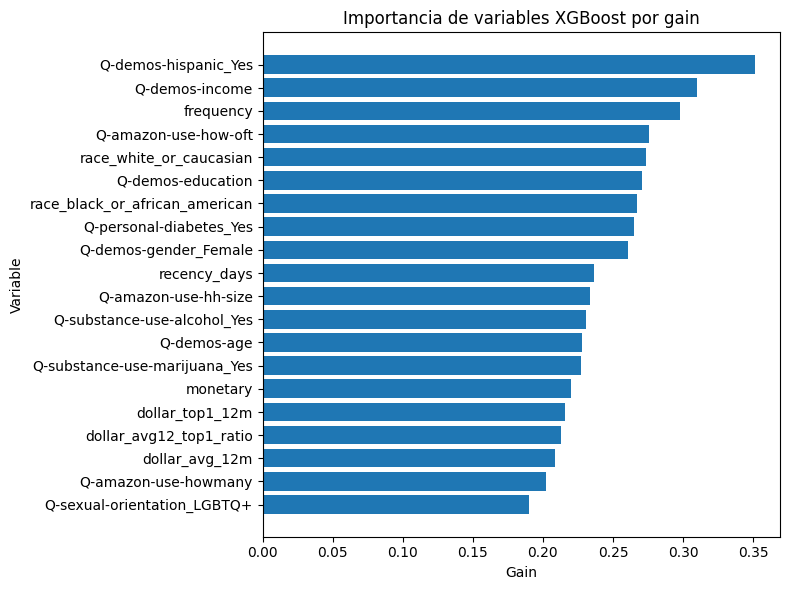

In [275]:
top20 = importance_gain_df.head(20).sort_values("gain")

plt.figure(figsize=(8, 6))
plt.barh(top20["feature"], top20["gain"])
plt.xlabel("Gain")
plt.ylabel("Variable")
plt.title("Importancia de variables XGBoost por gain")
plt.tight_layout()
plt.show()

In [278]:
importance_weight = xgb_model.get_booster().get_score(importance_type="weight")

importance_weight_df = pd.DataFrame([
    {
        "feature": feature_names[int(k.replace("f", ""))],
        "weight": v
    }
    for k, v in importance_weight.items()
    if int(k.replace("f", "")) < len(feature_names)
]).sort_values("weight", ascending=False)

importance_weight_df.head(30)

,feature,weight
0,recency_days,499.0
2,monetary,466.0
3,dollar_avg_12m,166.0
7,Q-demos-income,126.0
1,frequency,122.0
5,dollar_avg12_top1_ratio,111.0
4,dollar_top1_12m,102.0
9,Q-demos-age,92.0
11,Q-amazon-use-hh-size,88.0
6,Q-demos-education,77.0


In [277]:
indices_usados = [int(k.replace("f", "")) for k in importance_gain.keys()]

print("Índice máximo usado por XGBoost:", max(indices_usados))
print("Número de nombres:", len(feature_names))

Índice máximo usado por XGBoost: 36
Número de nombres: 38


In [279]:
indices_usados = {int(k.replace("f", "")) for k in importance_gain.keys()}
indices_todos = set(range(len(feature_names)))

indices_no_usados = indices_todos - indices_usados

variables_no_usadas = [feature_names[i] for i in sorted(indices_no_usados)]

variables_no_usadas

['n_states',
 'race_american_indian_native_american_or_alaska_native',
 'race_native_hawaiian_or_other_pacific_islander',
 'Q-demos-gender_Prefer not to say',
 'Q-sexual-orientation_prefer not to say',
 'Q-substance-use-cigarettes_Prefer not to say',
 'Q-substance-use-marijuana_Prefer not to say',
 'Q-substance-use-alcohol_I stopped in the recent past',
 'Q-substance-use-alcohol_Prefer not to say',
 'Q-personal-diabetes_Prefer not to say',
 'Q-personal-wheelchair_Prefer not to say']

In [281]:
importance_gain_df = pd.DataFrame([
    {
        "feature": feature_names[int(k.replace("f", ""))],
        "gain": v
    }
    for k, v in importance_gain.items()
]).sort_values("gain", ascending=False)

importance_gain_df.head(30)

,feature,gain
16,Q-demos-hispanic_Yes,0.351641
7,Q-demos-income,0.309793
1,frequency,0.297737
8,Q-amazon-use-how-oft,0.275510
12,race_white_or_caucasian,0.273553
6,Q-demos-education,0.270986
14,race_black_or_african_american,0.267061
25,Q-personal-diabetes_Yes,0.264859
17,Q-demos-gender_Female,0.260541
0,recency_days,0.236631


In [282]:
# Top variables según gain
top_features = importance_gain_df["feature"].head(20).tolist()

# Armar nuevas matrices solo con esas variables
X_train_sel = X_train[top_features].copy()
X_test_sel = X_test[top_features].copy()

In [283]:
numeric_cols_sel = [c for c in numeric_cols if c in X_train_sel.columns]
impute_cols_sel = [c for c in impute_cols if c in X_train_sel.columns]
cat_cols_sel = [c for c in X_train_sel.columns if c not in numeric_cols_sel + impute_cols_sel]

preprocessor_sel = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_cols_sel),
        ("impute", imputation_pipeline, impute_cols_sel),
        ("cat", "passthrough", cat_cols_sel)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

model_xgb_show_sel = Pipeline(steps=[
    ("preprocessor", preprocessor_sel),
    ("xgb", xgb_show)
])

model_xgb_show_sel.fit(X_train_sel, y_train)

y_pred_test_sel = model_xgb_show_sel.predict(X_test_sel)

In [284]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_sel = mean_absolute_error(y_test, y_pred_test_sel)
rmse_sel = np.sqrt(mean_squared_error(y_test, y_pred_test_sel))

print("MAE modelo original:", mae)
print("RMSE modelo original:", rmse)

print("MAE modelo reducido:", mae_sel)
print("RMSE modelo reducido:", rmse_sel)

MAE modelo original: 0.08945104235933114
RMSE modelo original: 0.1741738383554941
MAE modelo reducido: 0.09577380092295643
RMSE modelo reducido: 0.16965486042565298


In [285]:
resultados_seleccion = []

for k in [5, 10, 15, 20, 25, 30]:
    top_features = importance_gain_df["feature"].head(k).tolist()
    
    X_train_sel = X_train[top_features].copy()
    X_test_sel = X_test[top_features].copy()
    
    numeric_cols_sel = [c for c in numeric_cols if c in X_train_sel.columns]
    impute_cols_sel = [c for c in impute_cols if c in X_train_sel.columns]
    cat_cols_sel = [c for c in X_train_sel.columns if c not in numeric_cols_sel + impute_cols_sel]
    
    preprocessor_sel = ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_cols_sel),
            ("impute", imputation_pipeline, impute_cols_sel),
            ("cat", "passthrough", cat_cols_sel)
        ],
        remainder="drop",
        verbose_feature_names_out=False
    )
    
    model_sel = Pipeline(steps=[
        ("preprocessor", preprocessor_sel),
        ("xgb", xgb_show)
    ])
    
    model_sel.fit(X_train_sel, y_train)
    pred_sel = model_sel.predict(X_test_sel)
    
    resultados_seleccion.append({
        "top_k": k,
        "mae": mean_absolute_error(y_test, pred_sel),
        "rmse": np.sqrt(mean_squared_error(y_test, pred_sel))
    })

pd.DataFrame(resultados_seleccion)

,top_k,mae,rmse
0,5,0.100693,0.170036
1,10,0.101611,0.175105
2,15,0.093603,0.166346
3,20,0.095774,0.169655
4,25,0.095501,0.169718
5,30,0.096783,0.170374


### Comentario
Con el fin de evaluar si una selección de variables basada en la importancia del modelo mejoraba el desempeño predictivo, se entrenaron modelos XGBoost reducidos considerando diferentes subconjuntos de predictores ordenados según su importancia por gain. En particular, se evaluaron modelos con las 5, 10, 15, 20, 25 y 30 variables más relevantes.

Los resultados muestran que el mejor desempeño se obtuvo al conservar las 20 variables principales, con un MAE de 0.09577 y un RMSE de 0.16966. Sin embargo, este resultado no superó el desempeño del modelo completo, cuyo MAE fue de 0.08945 y RMSE de 0.17417. Aunque el modelo reducido con 20 variables presentó un RMSE ligeramente menor, el incremento en el MAE indica una pérdida de precisión promedio en la estimación del ShoW.

En consecuencia, la eliminación de variables no produjo una mejora clara del desempeño general. Por tanto, se conserva el modelo completo como especificación principal, dado que presenta el menor error absoluto promedio y mantiene una mayor capacidad para aprovechar posibles interacciones entre variables dentro de la estructura de árboles de XGBoost.
